In [1]:
"""Exploratory Data Analysis for the NASA C-MAPSS FD001 dataset."""

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))  # allow importing from src/ when running inside notebooks/
from src.data.make_dataset import load_fd001

RAW_DIR = Path("../data/raw")
data = load_fd001(RAW_DIR)
train_df = data["train"]

print(train_df.info())
print(train_df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_measurement_1   20631 non-null  float64
 6   sensor_measurement_2   20631 non-null  float64
 7   sensor_measurement_3   20631 non-null  float64
 8   sensor_measurement_4   20631 non-null  float64
 9   sensor_measurement_5   20631 non-null  float64
 10  sensor_measurement_6   20631 non-null  float64
 11  sensor_measurement_7   20631 non-null  float64
 12  sensor_measurement_8   20631 non-null  float64
 13  sensor_measurement_9   20631 non-null  float64
 14  sensor_measurement_10  20631 non-null  float64
 15  sensor_measur

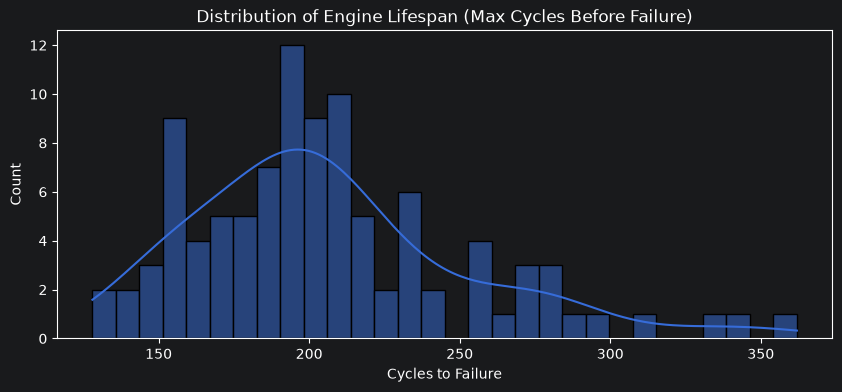

In [3]:
max_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()

plt.figure(figsize=(10, 4))
sns.histplot(max_cycles, bins=30, kde=True)
plt.title("Distribution of Engine Lifespan (Max Cycles Before Failure)")
plt.xlabel("Cycles to Failure")
plt.savefig("../reports/figures/lifespan_distribution.png")
plt.show()

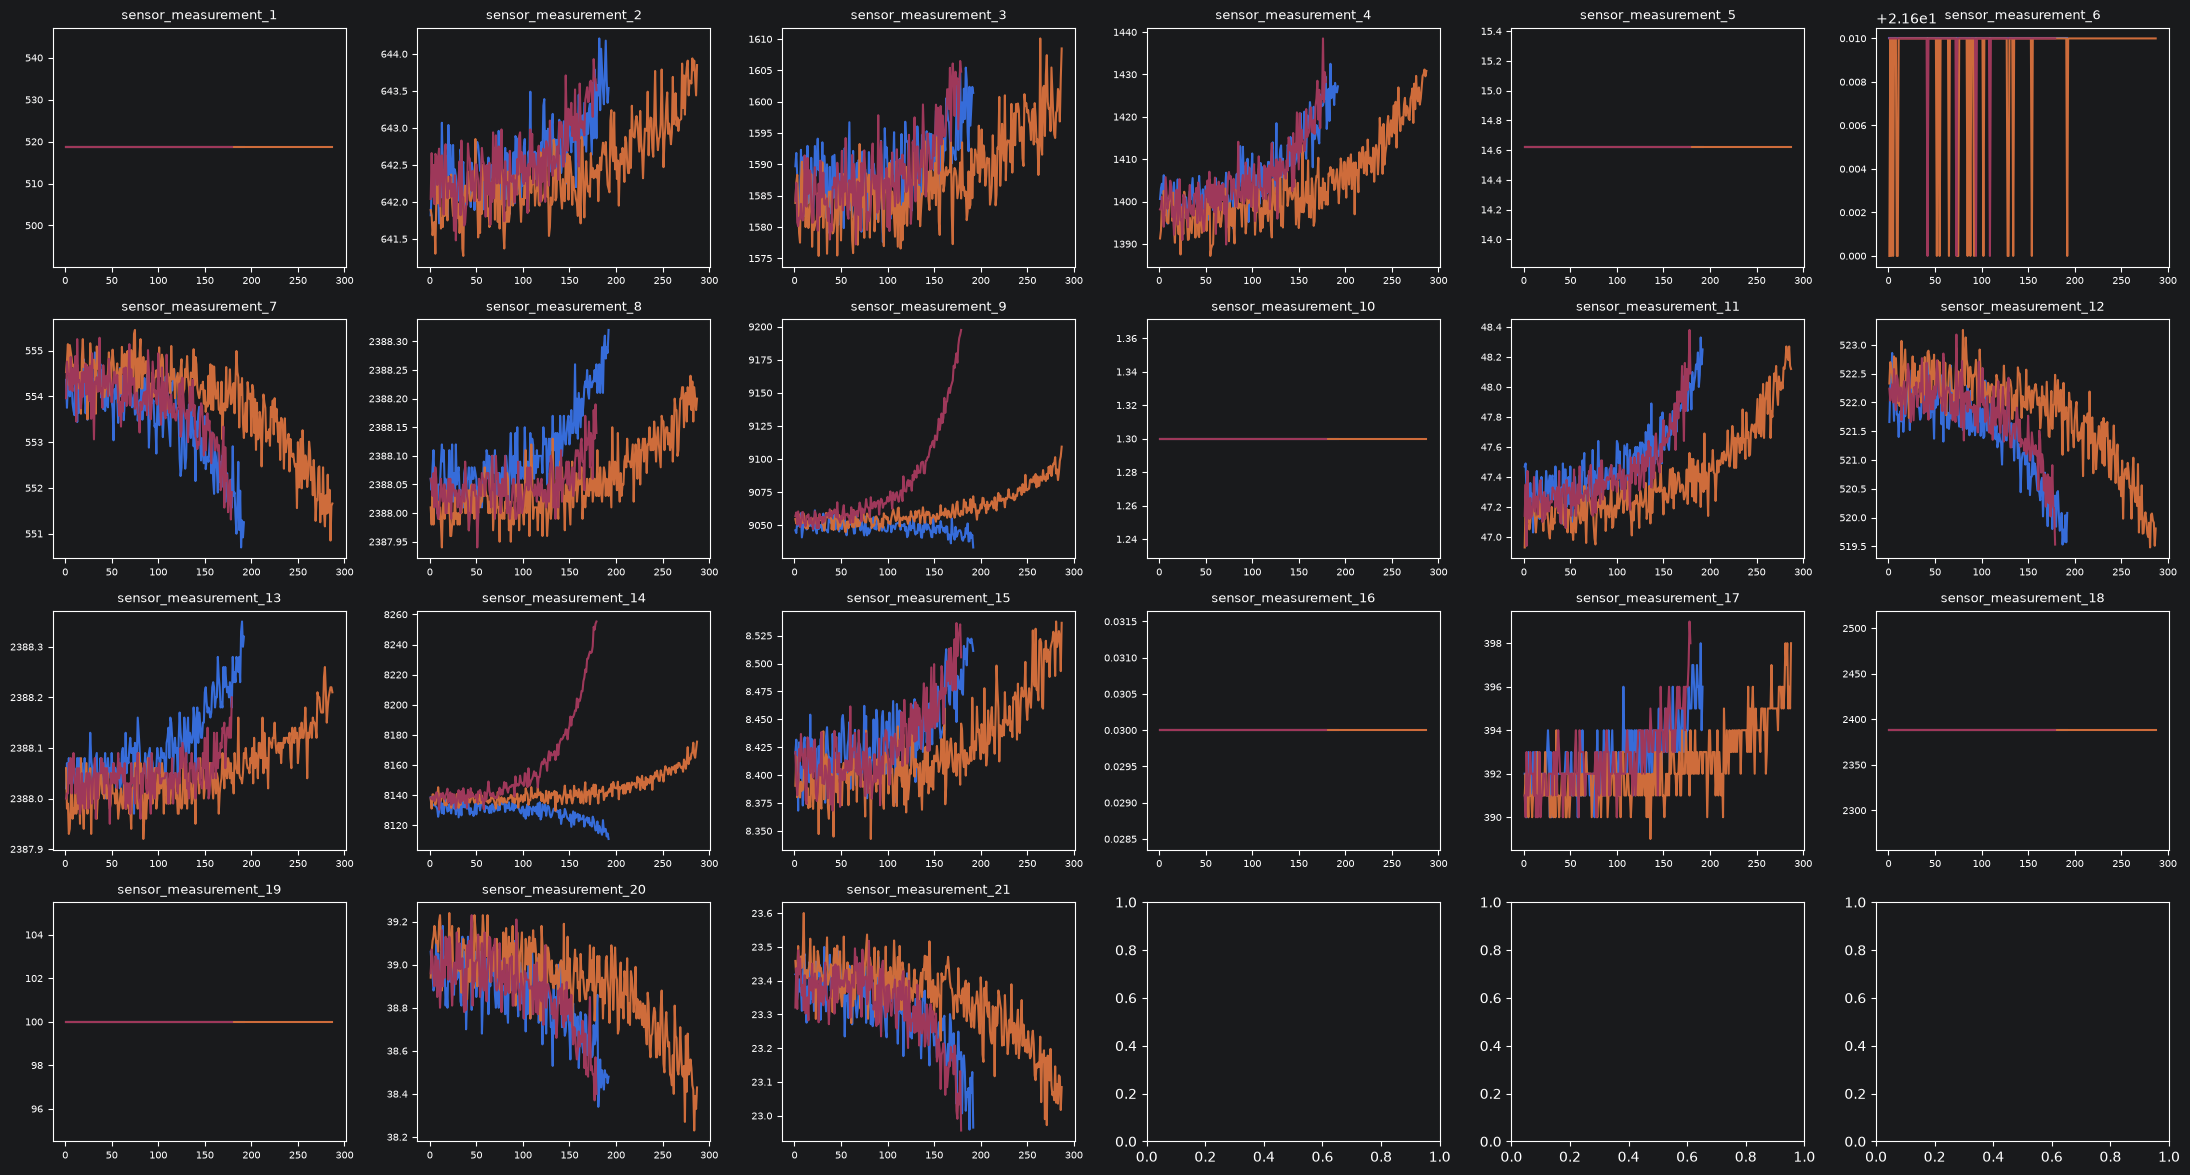

In [4]:
sensor_columns = [c for c in train_df.columns if c.startswith("sensor_measurement")]

sample_units = [1, 2, 3]
fig, axes = plt.subplots(4, 6, figsize=(22, 12))
axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):
    for unit in sample_units:
        unit_data = train_df[train_df["unit_number"] == unit]
        axes[i].plot(unit_data["time_in_cycles"], unit_data[sensor], label=f"Unit {unit}")
    axes[i].set_title(sensor, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("../reports/figures/sensor_trends.png")
plt.show()

In [5]:
sensor_std = train_df[sensor_columns].std()
low_variance_sensors = sensor_std[sensor_std < 0.01].index.tolist()

print("Sensors with near-zero variance (candidates for removal):")
print(low_variance_sensors)

Sensors with near-zero variance (candidates for removal):
['sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_6', 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18', 'sensor_measurement_19']


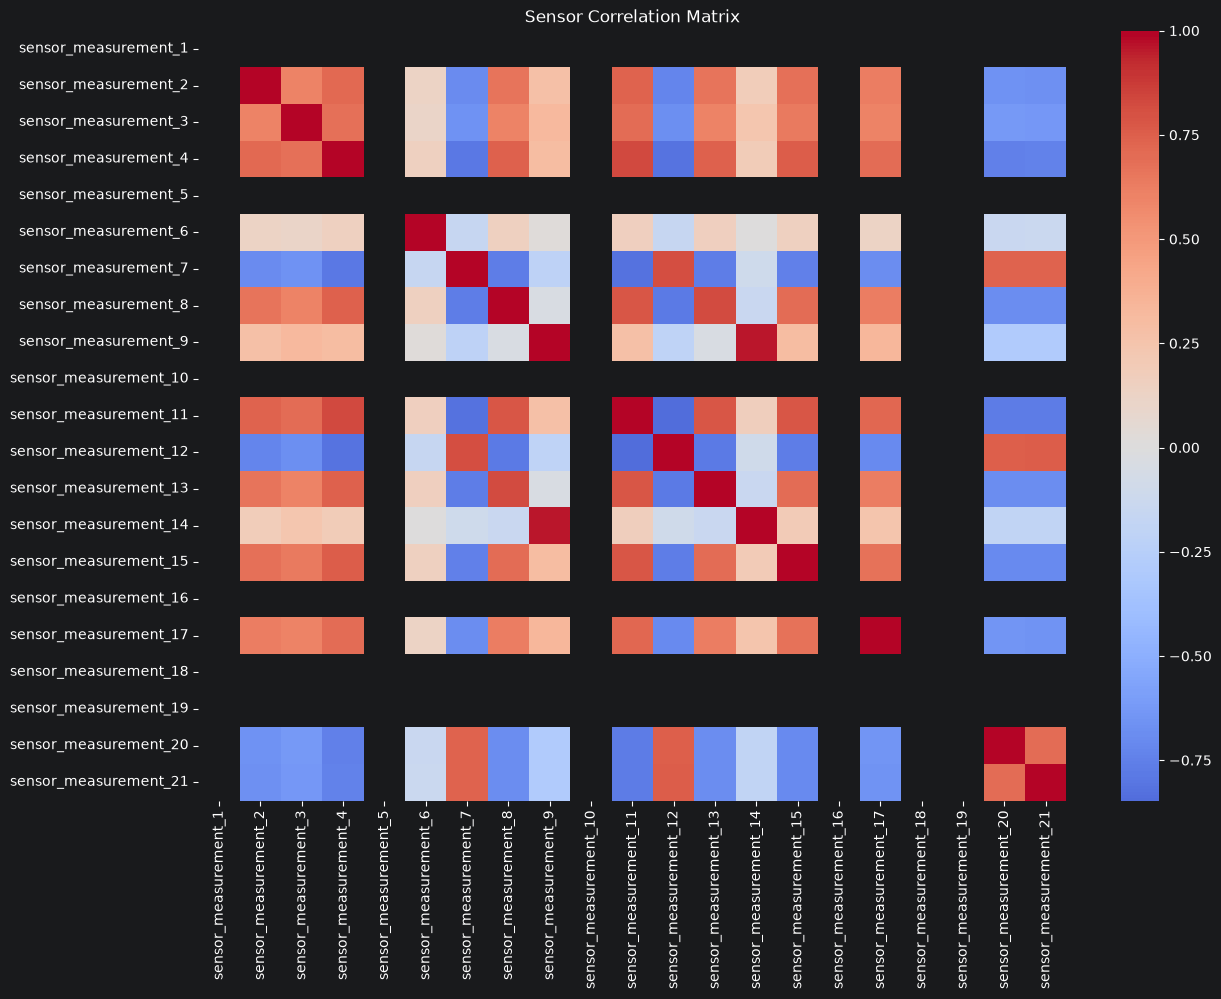

In [6]:
plt.figure(figsize=(14, 10))
corr_matrix = train_df[sensor_columns].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Sensor Correlation Matrix")
plt.savefig("../reports/figures/correlation_matrix.png")
plt.show()